# Example GFS wave forecast evaluation with SOFAR buoy network

In [1]:
import os
import xarray as xr
import cfgrib
import matplotlib.pyplot as plt
import numpy as np

%matplotlib widget

In [2]:
%load_ext autoreload
%autoreload 2

import ww3tools.sofar as sf

In [3]:
# Set up a Dask cluster
from dask_jobqueue import SLURMCluster
from dask.distributed import Client

cluster = SLURMCluster(
    queue='u1-compute',
    account='marine-cpu',
    cores=24,                       # CPU cores per worker job
    memory="8GB",                   # RAM per worker job
    walltime="02:00:00",            # Max runtime for the worker
)

# Request exactly 1 job from the SLURM scheduler (24 cores total)
cluster.scale(jobs=1)

# Connect your Jupyter notebook to this newly created cluster
client = Client(cluster)

/scratch3/NCEPDEV/marine/Edwin.Rainville/envs/sofar/lib/python3.14/site-packages/distributed/utils.py:200: RuntimeWarning: Couldn't detect a suitable IP address for reaching '8.8.8.8', defaulting to hostname: [Errno 101] Network is unreachable
  warnings.warn(


## Open the SOFAR data and concatenate over forecast length

In [4]:
# Find all netCDF SOFAR files in start and end dates of comparison
start_date = '2026-01-01'
end_date = '2026-01-16'
data_dir = '../../data/nc_data/'
file_pattern='sofar_b001_xx121_%Y%m%d.nc'
sofar_nc_files = sf.get_corresponding_files(data_dir, file_pattern, start_date, end_date, loop_type='date')

# 2. Automatically open and concatenate all of them along the time dimension
sofar_data = sf.combine_netcdf_files(sofar_nc_files, concat_dim="time")

sofar_data

<xarray.Dataset> Size: 9MB
Dimensions:    (time: 94646)
Coordinates:
  * time       (time) datetime64[ns] 757kB 2026-01-01T01:01:00 ... 2026-01-16...
Data variables:
    lat        (time) float32 379kB -41.47 -24.37 32.22 ... -33.85 30.73 -39.04
    lon        (time) float32 379kB 116.3 -12.77 -137.4 ... -10.05 -53.52 77.41
    lstn       (time) <U11 4MB 'SPOT-010382' 'SPOT-010415' ... 'SPOT-010094'
    buoy_type  (time) int32 379kB 9 9 9 9 9 9 9 9 9 9 9 ... 9 9 9 9 9 9 9 9 9 9
    hs         (time) float32 379kB 4.05 1.41 1.77 2.62 ... 2.53 1.16 1.83 2.48
    dsdw       (time) int32 379kB 12 26 29 48 32 45 30 ... 39 31 24 38 33 35 29
    ddwc       (time) int32 379kB 229 328 297 280 359 310 ... 349 0 184 145 214
    avwp       (time) float32 379kB 12.1 8.0 8.6 7.8 8.1 ... 9.5 7.5 7.0 5.8 6.7
    spwp       (time) float32 379kB 14.6 14.6 11.4 8.5 10.2 ... 9.3 7.9 7.9 10.2
    wspd       (time) float32 379kB 3.2 1.6 4.0 4.0 4.0 ... 4.4 5.6 0.8 6.8 8.4
    wdir       (time) float32 379kB 262.0 308.0 211.0 ... 142.0 160.0 268.0
Attributes:
    description:  Example sofar buoy data bufr
    source:       Converted from NCO BUFR data tanks

## Complete basic cleaning on the SOFAR data 

In [5]:
# Clean your concatenated dataset
threshold = 500 # Generic threshold for all variables for any particularly spurious data
sofar_data = sf.clean_sofar_data(sofar_data, threshold)

# ** Compute a difference between the cleaned and not cleaned dataset? 

sofar_data

<xarray.Dataset> Size: 6MB
Dimensions:    (time: 92058)
Coordinates:
  * time       (time) datetime64[ns] 736kB 2026-01-01T01:01:00 ... 2026-01-16...
Data variables:
    lat        (time) float32 368kB -41.47 -24.37 32.22 ... -33.85 30.73 -39.04
    lon        (time) float32 368kB 116.3 -12.77 -137.4 ... -10.05 -53.52 77.41
    lstn       (time) object 736kB 'SPOT-010382' 'SPOT-010415' ... 'SPOT-010094'
    buoy_type  (time) float64 736kB 9.0 9.0 9.0 9.0 9.0 ... 9.0 9.0 9.0 9.0 9.0
    hs         (time) float32 368kB 4.05 1.41 1.77 2.62 ... 2.53 1.16 1.83 2.48
    dsdw       (time) float64 736kB 12.0 26.0 29.0 48.0 ... 38.0 33.0 35.0 29.0
    ddwc       (time) float64 736kB 229.0 328.0 297.0 ... 184.0 145.0 214.0
    avwp       (time) float32 368kB 12.1 8.0 8.6 7.8 8.1 ... 9.5 7.5 7.0 5.8 6.7
    spwp       (time) float32 368kB 14.6 14.6 11.4 8.5 10.2 ... 9.3 7.9 7.9 10.2
    wspd       (time) float32 368kB 3.2 1.6 4.0 4.0 4.0 ... 4.4 5.6 0.8 6.8 8.4
    wdir       (time) float32 368kB 262.0 308.0 211.0 ... 142.0 160.0 268.0
Attributes:
    description:  Example sofar buoy data bufr
    source:       Converted from NCO BUFR data tanks

## Open the GFS wave Forecast as a dataset

In [6]:
# Plot the output from the forecast grib file 
gfs_fname = '../../data/gfs.20260101/00/wave/gridded/gfswave.t00z.global.0p25.f000.grib2'
gfs_ds = xr.open_dataset(gfs_fname, engine="cfgrib", backend_kwargs={'indexpath':''})
gfs_ds

<xarray.Dataset> Size: 79MB
Dimensions:              (latitude: 721, longitude: 1440, orderedSequenceData: 3)
Coordinates:
  * latitude             (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude            (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
  * orderedSequenceData  (orderedSequenceData) float64 24B 1.0 2.0 3.0
    time                 datetime64[ns] 8B ...
    step                 timedelta64[ns] 8B ...
    surface              float64 8B ...
    valid_time           datetime64[ns] 8B ...
Data variables: (12/13)
    ws                   (latitude, longitude) float32 4MB ...
    wdir                 (latitude, longitude) float32 4MB ...
    u                    (latitude, longitude) float32 4MB ...
    v                    (latitude, longitude) float32 4MB ...
    swh                  (latitude, longitude) float32 4MB ...
    perpw                (latitude, longitude) float32 4MB ...
    ...                   ...
    shww                 (latitude, longitude) float32 4MB ...
    shts                 (orderedSequenceData, latitude, longitude) float32 12MB ...
    mpww                 (latitude, longitude) float32 4MB ...
    mpts                 (orderedSequenceData, latitude, longitude) float32 12MB ...
    wvdir                (latitude, longitude) float32 4MB ...
    swdir                (orderedSequenceData, latitude, longitude) float32 12MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-09-23T17:52 GRIB to CDM+CF via cfgrib-0.9.1...

## Get all forecast data and concatenate along the time dimension

In [7]:
# 1. Get all GFS forecast files from the 00Z forecast
# * start and end dates are already defined above
data_dir = '../../data/gfs.20260101/00/wave/gridded/'
file_pattern = 'gfswave.t00z.global.0p25.f{fhr:03d}.grib2'
gfs_wave_grib_files = sf.get_corresponding_files(data_dir, file_pattern, start_date, end_date, loop_type='forecast_hour')

# 2. Automatically open and concatenate all of them along the time dimension
gfs_lazy_ds = sf.combine_grib_files(gfs_wave_grib_files, chunks={})

gfs_lazy_ds

<xarray.Dataset> Size: 10GB
Dimensions:              (time: 128, latitude: 721, longitude: 1440,
                          orderedSequenceData: 3)
Coordinates:
  * time                 (time) datetime64[ns] 1kB 2026-01-01 ... 2026-01-16T...
    step                 (time) timedelta64[ns] 1kB 00:00:00 ... 15 days 21:0...
  * latitude             (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude            (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
  * orderedSequenceData  (orderedSequenceData) float64 24B 1.0 2.0 3.0
    time_ref             datetime64[ns] 8B ...
    surface              float64 8B ...
    valid_time           datetime64[ns] 8B ...
Data variables: (12/13)
    ws                   (time, latitude, longitude) float32 532MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    wdir                 (time, latitude, longitude) float32 532MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    u                    (time, latitude, longitude) float32 532MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    v                    (time, latitude, longitude) float32 532MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    swh                  (time, latitude, longitude) float32 532MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    perpw                (time, latitude, longitude) float32 532MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    ...                   ...
    shww                 (time, latitude, longitude) float32 532MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    shts                 (time, orderedSequenceData, latitude, longitude) float32 2GB dask.array<chunksize=(1, 3, 721, 1440), meta=np.ndarray>
    mpww                 (time, latitude, longitude) float32 532MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    mpts                 (time, orderedSequenceData, latitude, longitude) float32 2GB dask.array<chunksize=(1, 3, 721, 1440), meta=np.ndarray>
    wvdir                (time, latitude, longitude) float32 532MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    swdir                (time, orderedSequenceData, latitude, longitude) float32 2GB dask.array<chunksize=(1, 3, 721, 1440), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-09-23T17:52 GRIB to CDM+CF via cfgrib-0.9.1...

## Interpolate the GFS forecast data onto the SOFAR Spotter Buoy locations in time and space

In [8]:
# Define your target output path
output_zarr_path = "../../data/gfs_interpolated_sofar.zarr"

if os.path.exists(output_zarr_path):
    print(f"Zarr store found. Loading collocated data from {output_zarr_path}...")
    # Open the existing pre-computed dataset
    gfs_interpolated_to_sofar = xr.open_zarr(output_zarr_path)
    
else:
    print("Zarr store not found. Building task graph for interpolation...")
    # 1. Define the lazy interpolation blueprint
    collocated_lazy = gfs_lazy_ds.interp(
        latitude=sofar_data["lat"],
        longitude=sofar_data["lon"],
        time=sofar_data["time"],
        method="linear"
    )

    print("Executing computation across HPC workers and streaming to Zarr...")
    # 2. Trigger the Dask computation and write directly to disk
    collocated_lazy.to_zarr(output_zarr_path)
    
    # 3. Read it back in as a finalized dataset
    gfs_interpolated_to_sofar = xr.open_zarr(output_zarr_path)
    print("Interpolation complete and saved.")

# Inspect the final interpolated version
gfs_interpolated_to_sofar

Zarr store found. Loading collocated data from ../../data/gfs_interpolated_sofar.zarr...


<xarray.Dataset> Size: 9MB
Dimensions:              (time: 92058, orderedSequenceData: 3)
Coordinates:
  * time                 (time) datetime64[ns] 736kB 2026-01-01T01:01:00 ... ...
    latitude             (time) float32 368kB dask.array<chunksize=(46029,), meta=np.ndarray>
    longitude            (time) float32 368kB dask.array<chunksize=(46029,), meta=np.ndarray>
    step                 (time) timedelta64[ns] 736kB dask.array<chunksize=(23015,), meta=np.ndarray>
  * orderedSequenceData  (orderedSequenceData) float64 24B 1.0 2.0 3.0
    surface              float64 8B ...
    time_ref             datetime64[ns] 8B ...
    valid_time           datetime64[ns] 8B ...
Data variables: (12/13)
    dirpw                (time) float32 368kB dask.array<chunksize=(92058,), meta=np.ndarray>
    mpts                 (time, orderedSequenceData) float32 1MB dask.array<chunksize=(92058, 1), meta=np.ndarray>
    mpww                 (time) float32 368kB dask.array<chunksize=(92058,), meta=np.ndarray>
    perpw                (time) float32 368kB dask.array<chunksize=(92058,), meta=np.ndarray>
    shts                 (time, orderedSequenceData) float32 1MB dask.array<chunksize=(92058, 1), meta=np.ndarray>
    shww                 (time) float32 368kB dask.array<chunksize=(92058,), meta=np.ndarray>
    ...                   ...
    swh                  (time) float32 368kB dask.array<chunksize=(92058,), meta=np.ndarray>
    u                    (time) float32 368kB dask.array<chunksize=(92058,), meta=np.ndarray>
    v                    (time) float32 368kB dask.array<chunksize=(92058,), meta=np.ndarray>
    wdir                 (time) float32 368kB dask.array<chunksize=(92058,), meta=np.ndarray>
    ws                   (time) float32 368kB dask.array<chunksize=(92058,), meta=np.ndarray>
    wvdir                (time) float32 368kB dask.array<chunksize=(92058,), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-09-23T17:25 GRIB to CDM+CF via cfgrib-0.9.1...

## Compute the difference between the GFS Forecast and SOFAR Spotter Obeservations

Text(0, 0.5, 'Significant Wave Height Residual, (Hs_gfs - Hs_sofar) [m]')

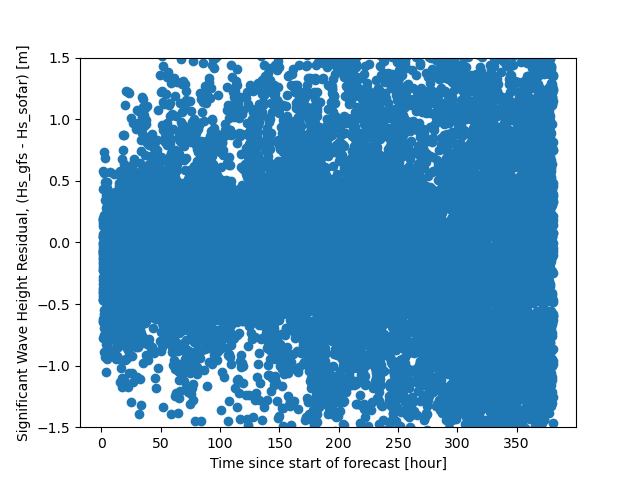

In [9]:
fig, ax = plt.subplots()
ax.scatter(gfs_interpolated_to_sofar['step'].values / np.timedelta64(1, 'h'), 
        gfs_interpolated_to_sofar['swh'].values - sofar_data['hs'].values)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('Time since start of forecast [hour]')
ax.set_ylabel('Significant Wave Height Residual, (Hs_gfs - Hs_sofar) [m]')